### Business Problem Statement


Context:
An online retailer in the UK wants to understand its customers better to increase sales, retention, and loyalty. Currently, there is no clear picture of who the high-value or repeat customers are, or which segments are at risk of churn.

Problem:
Without insights into customer behavior, purchasing patterns, and revenue contribution, marketing efforts are inefficient, and growth opportunities are being missed.

Objectives:

Identify top customers by purchase value and frequency.
Track monthly trends of new vs returning customers.
Segment customers using RFM (Recency, Frequency, Monetary) to target loyalty programs and retention strategies.
Understand revenue concentration, including contribution from top 20% of customers.

### Imports and settings (Code) 

In [185]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.2f}'.format

In [186]:
data_frame = pd.read_csv('D:\Data\projects\Online_Retail_UKE-commerce_2\data_set\Ecommerce.csv' ,encoding = 'latin-1' ,dtype = {'CustomerID':'object'} )

data_frame

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680,France


In [187]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  object 
 7   Country      541909 non-null  object 
dtypes: float64(1), int64(1), object(6)
memory usage: 33.1+ MB


In [188]:
data = data_frame.copy()

### Clenaing the data

In [189]:
data.columns = ['Invoice_No', 'Stock_Code', 'Description', 'Quantity', 'Invoice_Date','Unit_Price', 'Customer_ID', 'Country']
data.columns = data.columns.str.lower()

In [190]:
data['ivoice_data'] = pd.to_datetime(data['invoice_date'])
data['customer_id'] = data['customer_id'].astype('object')

In [191]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   invoice_no    541909 non-null  object        
 1   stock_code    541909 non-null  object        
 2   description   540455 non-null  object        
 3   quantity      541909 non-null  int64         
 4   invoice_date  541909 non-null  object        
 5   unit_price    541909 non-null  float64       
 6   customer_id   406829 non-null  object        
 7   country       541909 non-null  object        
 8   ivoice_data   541909 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 37.2+ MB


In [192]:
data.describe().round(0)

,quantity,unit_price,ivoice_data
count,"541,909.00","541,909.00",541909
mean,10.00,5.00,2011-07-04 13:34:57.156386048
min,"-80,995.00","-11,062.00",2010-12-01 08:26:00
25%,1.00,1.00,2011-03-28 11:34:00
50%,3.00,2.00,2011-07-19 17:17:00
75%,10.00,4.00,2011-10-19 11:27:00
max,"80,995.00","38,970.00",2011-12-09 12:50:00
std,218.00,97.00,NaN


In [193]:
data.describe(include= 'object')

,invoice_no,stock_code,description,invoice_date,customer_id,country
count,541909,541909,540455,541909,406829,541909
unique,25900,4070,4223,23260,4372,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,17841,United Kingdom
freq,1114,2313,2369,1114,7983,495478


In [194]:
data.isnull().sum()

invoice_no           0
stock_code           0
description       1454
quantity             0
invoice_date         0
unit_price           0
customer_id     135080
country              0
ivoice_data          0
dtype: int64

In [195]:
data.duplicated().sum()

5268

In [196]:
data = data.drop_duplicates()

In [197]:
data.duplicated().sum()

0

In [198]:
only_digit = data['stock_code'].str.match(r'^[A-Za-z\d]+$')

only_one_digit = data['stock_code'].str.count(r'\d') <=1

#data[~( data['stock_code'].str.match(r'^[A-Za-z\d]+$'))]
#data[( data['stock_code'].str.count(r'\d') <=1)]

result = data[(only_one_digit) & (only_digit)]
result['stock_code'].unique()

array(['POST', 'D', 'C2', 'DOT', 'M', 'S', 'AMAZONFEE', 'm', 'DCGSSBOY',
       'DCGSSGIRL', 'PADS', 'B', 'CRUK'], dtype=object)

In [199]:
resukt = result[['stock_code' , 'description']].drop_duplicates()

In [200]:
print(result['description'].to_list())
print(result['stock_code'].to_list())

['POSTAGE', 'Discount', 'POSTAGE', 'POSTAGE', 'CARRIAGE', 'DOTCOM POSTAGE', 'Manual', 'Manual', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'Manual', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'Manual', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'POSTAGE', 'Manual', 'Manual', 'Manual', 'Manual', 'Discount', 'POSTAGE', 'POSTAGE', 'Manual', 'POSTAGE', 'Manual', 'POSTAGE', 'Manual', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'CARRIAGE', 'Manual', 'CARRIAGE', 'Manual', 'Manual', 'POSTAGE', 'DOTCOM POSTAGE', 'Manual', 'POSTAGE', 'POSTAGE', 'Manual', 'SAMPLES', 'SAMPLES', 'POSTAGE', 'Discount', 'AMAZON FEE', 'Manual', 'Manual', 'AMAZON FEE', 'AMAZON FEE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'DOTCOM POSTAGE', 'AMAZON FEE', 'AMAZON FEE', 'AMAZON FEE', 'AMAZON FEE', 'DOTCOM POSTAGE', 'POSTAGE', 'POSTAGE', 'Manual', 'Manual', 'Manual', 'POSTAGE', 'DOTCOM POSTAGE', 'Discount', 

In [201]:
non_product = ['AMAZONFEE', 'B', 'C2',  'DOT', 'M', 'POST', 'S', 'm']
non_product_desc = ['AMAZON FEE', 'Adjust bad debt', 'CARRIAGE', np.nan,  'DOTCOM POSTAGE',  'POSTAGE', 'SAMPLES', 'Manual']

In [202]:
data =data[(~data['stock_code'].isin(non_product)) &  (~data['description'].isin(non_product_desc))].reset_index()

In [203]:
data['Month'] = data['ivoice_data'].dt.to_period('M').dt.to_timestamp()
data['total_sale'] =round( data['quantity'] * data['unit_price'] , 2)
data['is_return'] = data['quantity'] < 0

data_clean = data[(data['quantity'] > 0) & (data['unit_price'] >0)]

In [204]:
data_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 522583 entries, 0 to 532416
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   index         522583 non-null  int64         
 1   invoice_no    522583 non-null  object        
 2   stock_code    522583 non-null  object        
 3   description   522583 non-null  object        
 4   quantity      522583 non-null  int64         
 5   invoice_date  522583 non-null  object        
 6   unit_price    522583 non-null  float64       
 7   customer_id   391165 non-null  object        
 8   country       522583 non-null  object        
 9   ivoice_data   522583 non-null  datetime64[ns]
 10  Month         522583 non-null  datetime64[ns]
 11  total_sale    522583 non-null  float64       
 12  is_return     522583 non-null  bool          
dtypes: bool(1), datetime64[ns](2), float64(2), int64(2), object(6)
memory usage: 52.3+ MB


In [205]:
data_clean[['invoice_no' , 'stock_code', 'ivoice_data']].duplicated().sum()

5242

In [206]:
data_clean_group = data_clean.groupby(['invoice_no', 'stock_code'] ,as_index= False ).agg(
    quantity = ('quantity' ,'sum'),
    total_sale = ('total_sale' ,'sum'),
    unit_price = ('unit_price' , 'first'),
    description = ('description' , 'first'),
    invoice_date = ('invoice_date' , 'first'),
    customer_id = ('customer_id'  ,'first'),
    country = ('country' , 'first')
)
data_clean_group

,invoice_no,stock_code,quantity,total_sale,unit_price,description,invoice_date,customer_id,country
0,536365,21730,6,25.50,4.25,GLASS STAR FROSTED T-LIGHT HOLDER,12/1/2010 8:26,17850,United Kingdom
1,536365,22752,2,15.30,7.65,SET 7 BABUSHKA NESTING BOXES,12/1/2010 8:26,17850,United Kingdom
2,536365,71053,6,20.34,3.39,WHITE METAL LANTERN,12/1/2010 8:26,17850,United Kingdom
3,536365,84029E,6,20.34,3.39,RED WOOLLY HOTTIE WHITE HEART.,12/1/2010 8:26,17850,United Kingdom
4,536365,84029G,6,20.34,3.39,KNITTED UNION FLAG HOT WATER BOTTLE,12/1/2010 8:26,17850,United Kingdom
...,...,...,...,...,...,...,...,...,...
517329,581587,22730,4,15.00,3.75,ALARM CLOCK BAKELIKE IVORY,12/9/2011 12:50,12680,France
517330,581587,22899,6,12.60,2.10,CHILDREN'S APRON DOLLY GIRL,12/9/2011 12:50,12680,France
517331,581587,23254,4,16.60,4.15,CHILDRENS CUTLERY DOLLY GIRL,12/9/2011 12:50,12680,France
517332,581587,23255,4,16.60,4.15,CHILDRENS CUTLERY CIRCUS PARADE,12/9/2011 12:50,12680,France


In [207]:
data_clean_group[['stock_code', 'invoice_date' , 'invoice_no']].duplicated().sum()

0

In [208]:
data_clean_group['invoice_date']  = pd.to_datetime(data_clean_group['invoice_date'] )
data_clean_group['month'] = data_clean_group['invoice_date'].dt.to_period("M").dt.to_timestamp()

In [209]:
print(data_clean_group['invoice_date'].min())
print(data_clean_group['invoice_date'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [210]:
data_known = data_clean_group[data_clean_group['customer_id'].notna()]
data_known = data_known[data_known['quantity'] >0]
data_known

,invoice_no,stock_code,quantity,total_sale,unit_price,description,invoice_date,customer_id,country,month
0,536365,21730,6,25.50,4.25,GLASS STAR FROSTED T-LIGHT HOLDER,2010-12-01 08:26:00,17850,United Kingdom,2010-12-01
1,536365,22752,2,15.30,7.65,SET 7 BABUSHKA NESTING BOXES,2010-12-01 08:26:00,17850,United Kingdom,2010-12-01
2,536365,71053,6,20.34,3.39,WHITE METAL LANTERN,2010-12-01 08:26:00,17850,United Kingdom,2010-12-01
3,536365,84029E,6,20.34,3.39,RED WOOLLY HOTTIE WHITE HEART.,2010-12-01 08:26:00,17850,United Kingdom,2010-12-01
4,536365,84029G,6,20.34,3.39,KNITTED UNION FLAG HOT WATER BOTTLE,2010-12-01 08:26:00,17850,United Kingdom,2010-12-01
...,...,...,...,...,...,...,...,...,...,...
517329,581587,22730,4,15.00,3.75,ALARM CLOCK BAKELIKE IVORY,2011-12-09 12:50:00,12680,France,2011-12-01
517330,581587,22899,6,12.60,2.10,CHILDREN'S APRON DOLLY GIRL,2011-12-09 12:50:00,12680,France,2011-12-01
517331,581587,23254,4,16.60,4.15,CHILDRENS CUTLERY DOLLY GIRL,2011-12-09 12:50:00,12680,France,2011-12-01
517332,581587,23255,4,16.60,4.15,CHILDRENS CUTLERY CIRCUS PARADE,2011-12-09 12:50:00,12680,France,2011-12-01


### EDA / Analysis sections

#### 1. How many unique customers made purchases during the observation period?

In [211]:
unique_customer = data_known['customer_id'].nunique()
unique_customer

4335

#### 2. How Many active customers in every months  ?

In [212]:
monthly_active_customers = (
    data_known
    .groupby('month' )['customer_id']
    .nunique()
)
monthly_active_customers

month
2010-12-01     885
2011-01-01     739
2011-02-01     757
2011-03-01     973
2011-04-01     853
2011-05-01    1055
2011-06-01     990
2011-07-01     946
2011-08-01     933
2011-09-01    1261
2011-10-01    1361
2011-11-01    1661
2011-12-01     615
Name: customer_id, dtype: int64

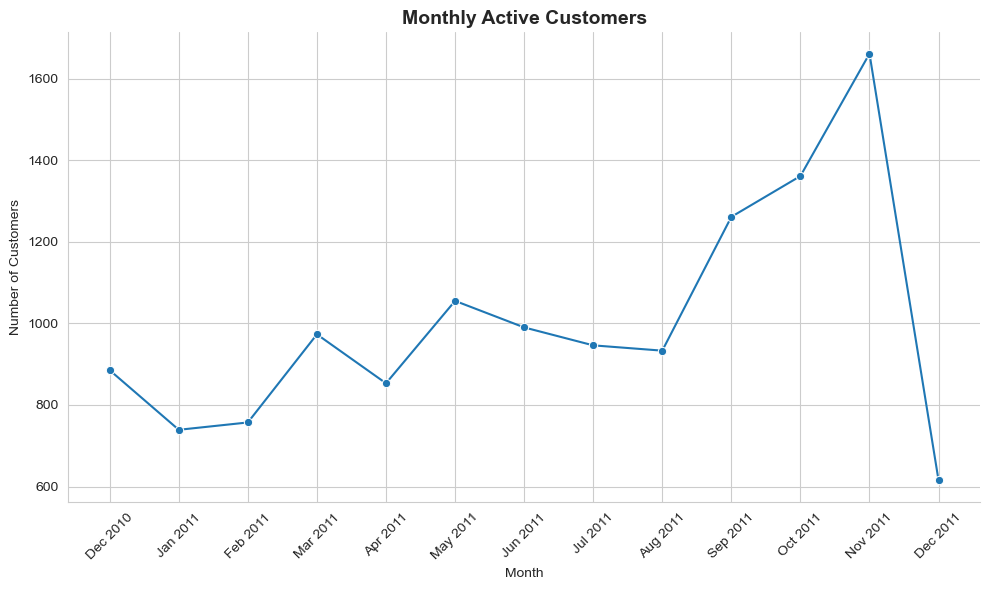

In [213]:
plt.figure(figsize=(10,6))

sns.lineplot(
    x=monthly_active_customers.index.strftime('%b %Y'),
    y=monthly_active_customers.values,
    marker='o'
)

plt.title("Monthly Active Customers", fontsize=14, weight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
sns.despine()

plt.tight_layout()
plt.show()

The number of customers shows an overall increasing trend throughout the year. However, temporary drops are observed in April and August, before reaching a strong peak in November, indicating possible seasonal purchasing behavior.

3️⃣ Monthly trend of new vs returning customers

In [214]:
first_purchase = (
    data_known
    .groupby('customer_id')['month']
    .min()
)
first_purchase

customer_id
12346   2011-01-01
12347   2010-12-01
12348   2010-12-01
12349   2011-11-01
12350   2011-02-01
           ...    
18280   2011-03-01
18281   2011-06-01
18282   2011-08-01
18283   2011-01-01
18287   2011-05-01
Name: month, Length: 4335, dtype: datetime64[ns]

In [215]:
data_known['customer_type'] = data_known.apply(
    lambda x: 'New' if x['month'] == first_purchase[x['customer_id']]
    else 'Returning',
    axis=1
)

In [216]:
customer_type_monthly = (
    data_known
    .groupby(['month','customer_type'])['customer_id']
    .nunique()
    .unstack()
)
customer_type_monthly

customer_type,New,Returning
month,,
2010-12-01,885.00,NaN
2011-01-01,416.00,323.00
2011-02-01,380.00,377.00
2011-03-01,452.00,521.00
2011-04-01,300.00,553.00
2011-05-01,284.00,771.00
2011-06-01,242.00,748.00
2011-07-01,187.00,759.00
2011-08-01,169.00,764.00


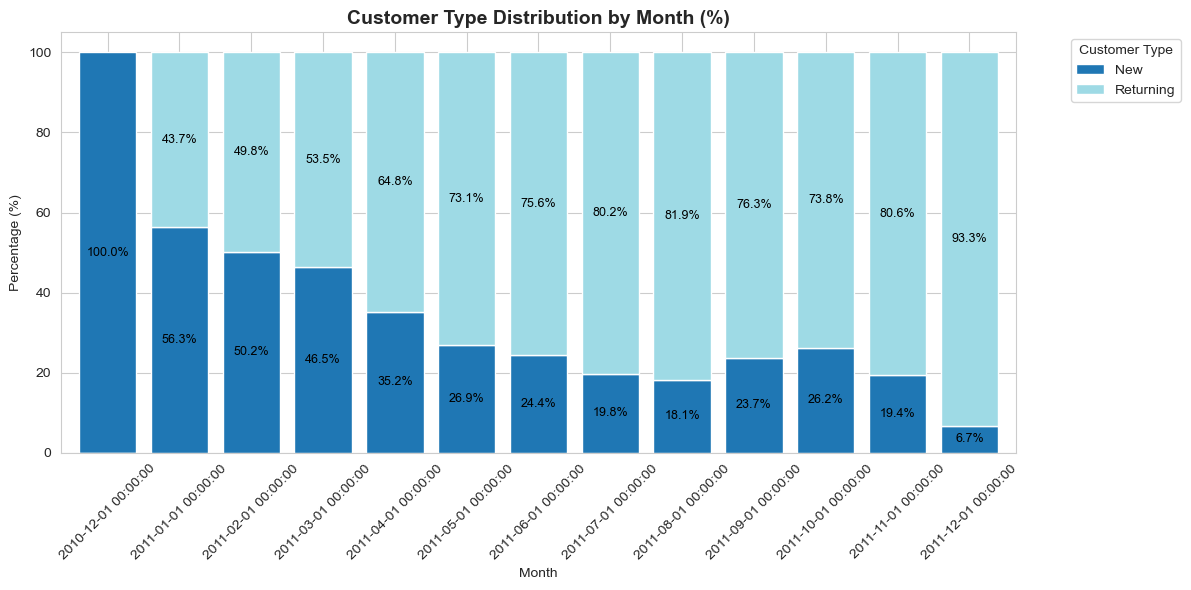

In [ ]:
# Normalize to percentages
customer_type_percent = customer_type_monthly.div(customer_type_monthly.sum(axis=1), axis=0) * 100

# Plot
ax = customer_type_percent.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    colormap='tab20',
    width=0.8
)

# Titles and labels
plt.title('Customer Type Distribution by Month (%)', fontsize=14, weight='bold')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.ylabel('Percentage (%)')

# Add percentage labels in dark color
for i, month in enumerate(customer_type_percent.index):
    cumulative = 0
    for cust_type in customer_type_percent.columns:
        value = customer_type_percent.loc[month, cust_type]
        if value > 0:  # only label segments with >0%
            ax.text(
                i, 
                cumulative + value/2,  # middle of the segment
                f'{value:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=9,
                color='black'  # dark color for text
            )
            cumulative += value

# Move legend outside
plt.legend(title='Customer Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

he share of new customers relative to returning customers gradually increased over the months, reaching around 20% in November, which indicates growing customer acquisition over time.

4️⃣ Countries with highest number of customers

In [218]:
customers_by_country = (
    data_known
    .groupby('country')['customer_id']
    .nunique()
    .sort_values(ascending=False)
    .head(5)
)
customers_by_country

country
United Kingdom    3917
Germany             94
France              87
Spain               30
Belgium             25
Name: customer_id, dtype: int64

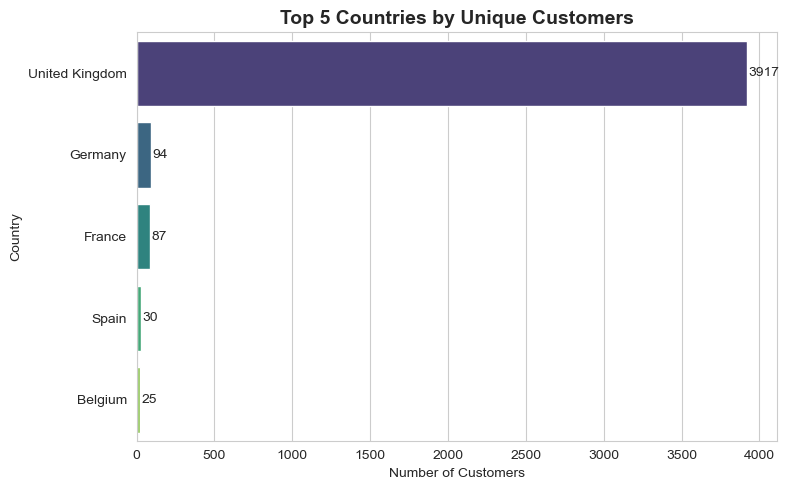

In [219]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=customers_by_country.values, 
    y=customers_by_country.index, 
    palette='viridis'
)

plt.title('Top 5 Countries by Unique Customers', fontsize=14, weight='bold')
plt.xlabel('Number of Customers')
plt.ylabel('Country')

# Add value labels
for i, v in enumerate(customers_by_country.values):
    plt.text(v + 10, i, str(v), va='center')

plt.tight_layout()
plt.show()

Almost all customers are located in the United Kingdom

5️⃣ Top customers by total purchase value

In [220]:
top_customers_value = (
    data_known
    .groupby('customer_id')['total_sale']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_customers_value

customer_id
14646   279,138.02
18102   259,657.30
17450   194,390.79
16446   168,472.50
14911   136,161.83
12415   124,564.53
14156   116,560.08
17511    91,062.38
12346    77,183.60
16029    72,708.09
Name: total_sale, dtype: float64

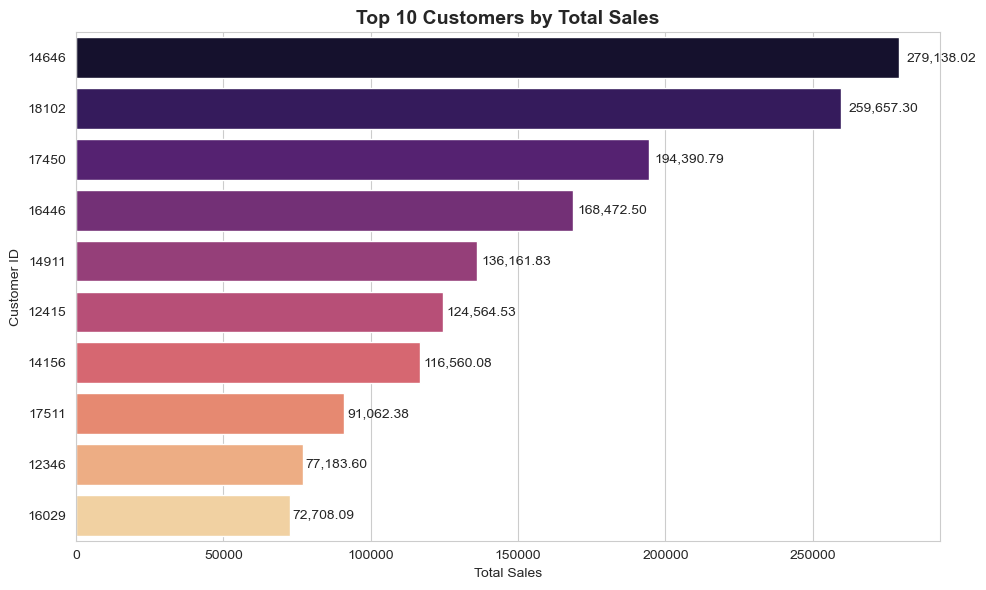

In [221]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_customers_value.values,
    y=top_customers_value.index.astype(str),  # in case customer_id is numeric
    palette='magma'
)

plt.title('Top 10 Customers by Total Sales', fontsize=14, weight='bold')
plt.xlabel('Total Sales')
plt.ylabel('Customer ID')

# Add value labels
for i, v in enumerate(top_customers_value.values):
    plt.text(v + 0.01*v, i, f'{v:,.2f}', va='center')

plt.tight_layout()
plt.show()

6️⃣ Most frequent customers (by number of orders)

In [222]:
top_customers_orders = (
    data_known
    .groupby('customer_id')['invoice_no']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
)
top_customers_orders

customer_id
12748    206
14911    198
17841    124
13089     97
15311     91
14606     91
12971     86
14646     72
16029     62
13408     62
Name: invoice_no, dtype: int64

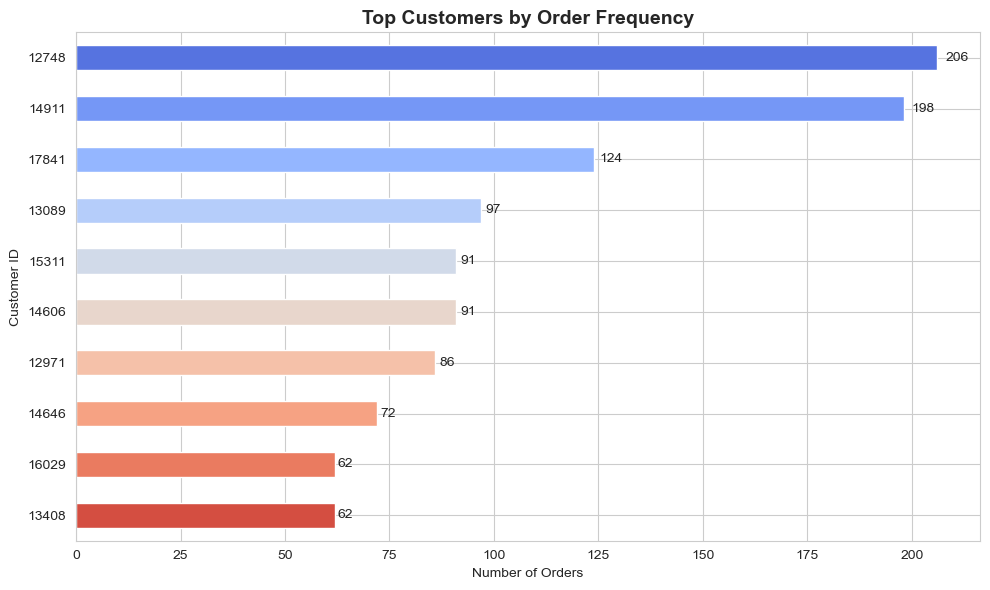

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot horizontal bar chart
top_customers_orders.plot(
    kind='barh',
    figsize=(10,6),
    color=sns.color_palette("coolwarm", len(top_customers_orders))  # nicer colors
)

plt.title("Top Customers by Order Frequency", fontsize=14, weight='bold')
plt.xlabel("Number of Orders")
plt.ylabel("Customer ID")

# Invert y-axis so the top customer appears at the top
plt.gca().invert_yaxis()

# Add value labels
for i, v in enumerate(top_customers_orders.values):
    plt.text(v + 0.01*v, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

7️⃣ Distribution of customer purchase frequency

In [224]:
customer_orders_distribution = (
    data_known
    .groupby('customer_id')['invoice_no']
    .nunique()
)
customer_orders_distribution

customer_id
12346     1
12347     7
12348     4
12349     1
12350     1
         ..
18280     1
18281     1
18282     2
18283    16
18287     3
Name: invoice_no, Length: 4335, dtype: int64

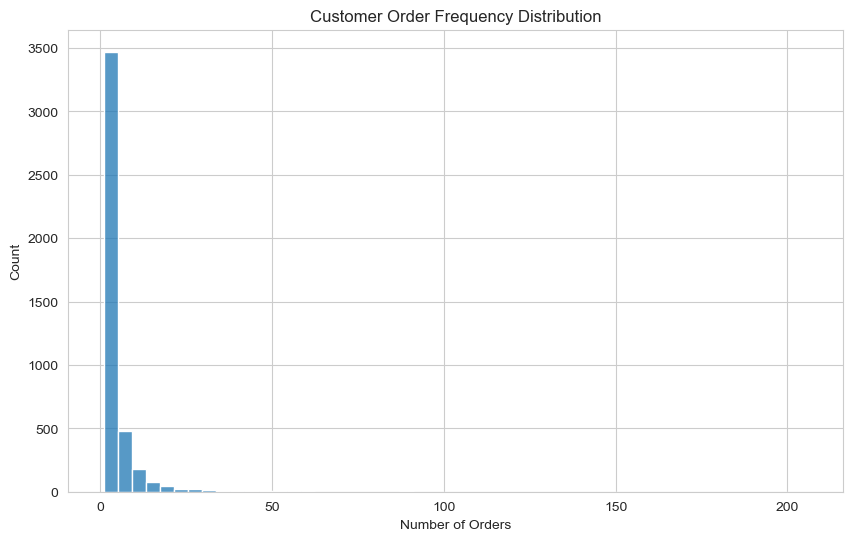

In [237]:
plt.figure(figsize=(10,6))

sns.histplot(customer_orders_distribution, bins=50)

plt.title("Customer Order Frequency Distribution")
plt.xlabel("Number of Orders")

plt.show()

The majority of customers placed between 1 and 5 orders, with the overall number of orders ranging from 1 to 20. However, customers who placed more than 9 orders represent only a small segment, indicating that high-frequency purchasing behavior is relatively rare.

### RFM Analysis

 Step 1: Calculate RFM Metrics

In [226]:
data_known.columns

Index(['invoice_no', 'stock_code', 'quantity', 'total_sale', 'unit_price',
       'description', 'invoice_date', 'customer_id', 'country', 'month',
       'customer_type'],
      dtype='object')

In [227]:
#data_known['order_date'] = pd.to_datetime(orders['order_date'])
current_date = data_known['invoice_date'].max()

rfm = data_known.groupby('customer_id').agg({
    'invoice_date': lambda x: (current_date - x.max()).days,
    'invoice_no': 'count',
    'total_sale': ['sum', 'mean']
})

rfm.columns = ['recency_days', 'frequency', 'monetary_value', 'avg_order_value']
rfm = rfm.reset_index()
print(rfm.sort_values('monetary_value', ascending=False).head())

     customer_id  recency_days  frequency  monetary_value  avg_order_value
1689       14646             1       2060      279,138.02           135.50
4198       18102             0        431      259,657.30           602.45
3726       17450             7        336      194,390.79           578.54
3007       16446             0          3      168,472.50        56,157.50
1879       14911             0       5584      136,161.83            24.38


Step 2: Assign RFM Scores (1-4 scale)

In [228]:
rfm['r_score'] = pd.qcut(rfm['recency_days'], q=4, labels=[4, 3, 2, 1])
rfm['f_score'] = pd.qcut(rfm['frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['m_score'] = pd.qcut(rfm['monetary_value'].rank(method='first'), q=4, labels=[1, 2, 3, 4])

rfm['r_score'] = rfm['r_score'].astype(int)
rfm['f_score'] = rfm['f_score'].astype(int)
rfm['m_score'] = rfm['m_score'].astype(int)
rfm['rfm_total_score'] = rfm['r_score'] + rfm['f_score'] + rfm['m_score']

print(rfm[['customer_id', 'r_score', 'f_score', 'm_score', 'rfm_total_score']]
      .sort_values('rfm_total_score', ascending=False).head())

     customer_id  r_score  f_score  m_score  rfm_total_score
2167       15298        4        4        4               12
2535       15796        4        4        4               12
581        13113        4        4        4               12
582        13115        4        4        4               12
2673       15993        4        4        4               12


 Step 3: Create Customer Segments


In [229]:
def segment_customer(row):
    r, f, m = row['r_score'], row['f_score'], row['m_score']

    if r >= 3 and f >= 3 and m >= 3:
        return 'Champions'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f == 1:
        return 'Promising'
    elif r == 2 and f >= 2:
        return 'Potential Loyalists'
    elif r == 2 and f == 1:
        return 'Needs Attention'
    elif r == 1 and f >= 3:
        return 'At Risk'
    elif r == 1 and f == 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['customer_segment'] = rfm.apply(segment_customer, axis=1)
print(rfm[['customer_id', 'r_score', 'f_score', 'm_score', 'customer_segment']].head(10))

  customer_id  r_score  f_score  m_score     customer_segment
0       12346        1        1        4                 Lost
1       12347        4        4        4            Champions
2       12348        2        2        3  Potential Loyalists
3       12349        3        3        3            Champions
4       12350        1        1        1                 Lost
5       12352        3        3        3            Champions
6       12353        1        1        1                 Lost
7       12354        1        3        3              At Risk
8       12355        1        1        2                 Lost
9       12356        3        3        4            Champions


Step 4: Segment Summary Statistics

                     customer_count  total_revenue  avg_customer_value  \
customer_segment                                                         
Champions                      1295   6,283,802.39            4,852.36   
Potential Loyalists             776     959,366.68            1,236.30   
Loyal Customers                 607     378,963.69              624.32   
Promising                       280     299,820.13            1,070.79   
Lost                            506     298,053.74              589.04   
At Risk                         217     235,631.76            1,085.86   
Hibernating                     356     162,288.18              455.87   
Needs Attention                 298     119,466.07              400.89   

                     pct_of_customers  
customer_segment                       
Champions                       29.87  
Potential Loyalists             17.90  
Loyal Customers                 14.00  
Promising                        6.46  
Lost               

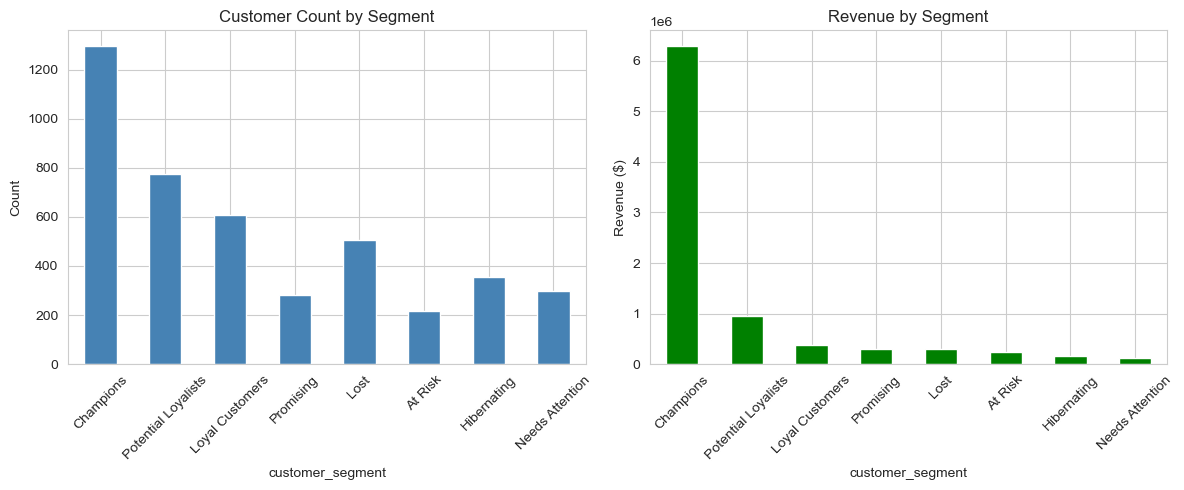

In [230]:

segment_summary = rfm.groupby('customer_segment').agg({
    'customer_id': 'count',
    'monetary_value': ['sum', 'mean']
}).round(2)

segment_summary.columns = ['customer_count', 'total_revenue', 'avg_customer_value']
segment_summary['pct_of_customers'] = (segment_summary['customer_count'] /
                                        segment_summary['customer_count'].sum() * 100).round(2)
segment_summary = segment_summary.sort_values('total_revenue', ascending=False)
print(segment_summary)

# Visualization
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
segment_summary['customer_count'].plot(kind='bar', color='steelblue')
plt.title('Customer Count by Segment')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
segment_summary['total_revenue'].plot(kind='bar', color='green')
plt.title('Revenue by Segment')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

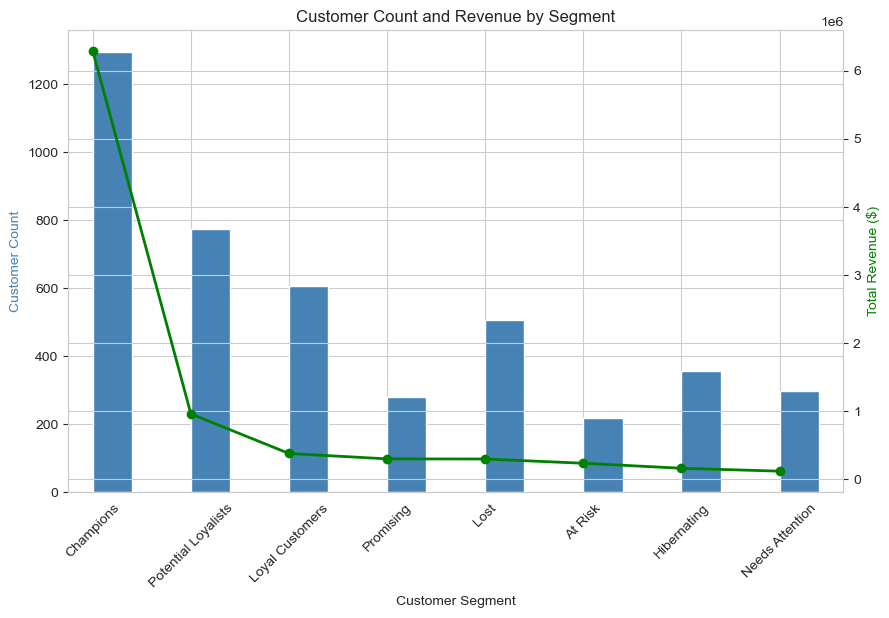

In [231]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()
segment_summary['customer_count'].plot(kind='bar', ax=ax1, color='steelblue', width=0.4, position=0)
segment_summary['total_revenue'].plot(kind='line', ax=ax2, color='green', marker='o', linewidth=2)

ax1.set_xlabel('Customer Segment')
ax1.set_ylabel('Customer Count', color='steelblue')
ax2.set_ylabel('Total Revenue ($)', color='green')
plt.title('Customer Count and Revenue by Segment')
ax1.set_xticklabels(segment_summary.index, rotation=45)
plt.show()

The Champions segment represents the largest and most valuable customer group, contributing the highest revenue share. The Potential Loyalists segment also includes a large number of customers and offers strong opportunities for future growth if properly targeted. In contrast, the Lost segment contains many customers but generates relatively low revenue, highlighting customer churn and the need for re-engagement strategies

Revenue from Top 20% Customers

In [232]:
customer_sales = (
    data_raw_analysis
    .groupby('customer_id')['total_sale']
    .sum()
    .sort_values(ascending=False)
)

top_20 = int(len(customer_sales) * 0.20)

top_20_sales = customer_sales.head(top_20).sum()

total_sales = customer_sales.sum()

percentage = round((top_20_sales / total_sales) * 100 , 1)

percentage

74.6

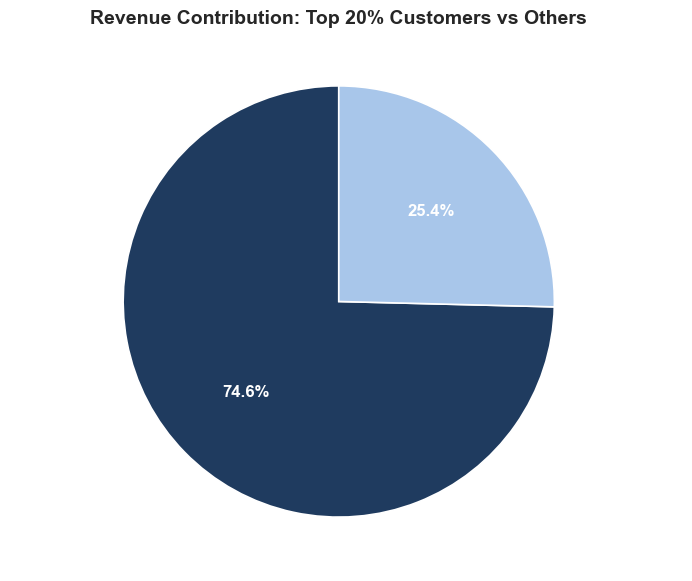

In [ ]:
import matplotlib.pyplot as plt

labels = ['Top 20% Customers', 'Other 80% Customers']
values = [top_20_sales, total_sales - top_20_sales]

colors = ['#1f3b5f', '#a8c6ea']  

plt.figure(figsize=(7,7))
plt.pie(
    values,
    labels=labels,
    colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 0 else '', 
    pctdistance=0.6, 
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
    textprops={'color': 'white', 'weight': 'bold', 'fontsize': 12}  # اللون أبيض
)
plt.title('Revenue Contribution: Top 20% Customers vs Others', fontsize=14, weight='bold')
plt.show()

Around 74% of total revenue comes from the top 20% of customers, highlighting a clear customer value concentration and emphasizing the importance of retaining and targeting high-value customers.

 ### Customer Insights Summary

The dominant customer base is located in the United Kingdom, suggesting that the business operates primarily within a single geographic market. Therefore, marketing efforts should continue focusing on this region to maximize impact and efficiency.

The conversion rate from new customers to returning customers appears strong and continues to improve over time, indicating effective customer acquisition and retention strategies. It is recommended to continue investing in targeted marketing campaigns to sustain this growth.


There is clear variation between low-frequency and high-frequency customers, indicating a diverse customer base with different purchasing behaviors, which is a positive sign for long-term business stability.


Most customers place between one and five orders. Therefore, strategies should be developed to increase purchase frequency through personalized offers, reminders, and loyalty incentives.


The Champions segment represents the most valuable customer group, as they are both the most active and the highest contributors to revenue. It is recommended to create exclusive loyalty campaigns to encourage continued engagement and additional purchases.


The Potential Loyalists segment also represents a promising group with strong future value. Targeted campaigns should be designed to convert them into Champions through personalized communication and incentives.



Overall, the analysis shows that revenue is strongly driven by high-value customer segments such as Champions and Potential Loyalists, while most customers still have relatively low purchase frequency. This creates a clear opportunity to increase revenue by improving customer retention and encouraging repeat purchases through targeted loyalty strategie